## Imports

Nesta seção são importadas as bibliotecas necessárias para:
- carregar e manipular dados (`pandas`, `numpy`);
- plotar gráficos (`matplotlib`);
- criar e avaliar modelos de regressão (`sklearn`).

In [1]:
# import libraries
import pandas as pd
import numpy as np
from sklearn import cluster as ct
from sklearn import metrics as mt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as ss
from matplotlib import pyplot as plt
from IPython.display import clear_output
import time

## Dataset

Neste bloco são carregados os conjuntos de dados de treino, validação e teste.

In [2]:
X_train = pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/Ensaio de Clusterização/Dados para o agrupamento/X_dataset.csv')
X_train.head()

,alcohol,malic_acid,ash,ash_alcanity,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280,proline
0,1.518613,0.191700,0.232053,-1.169593,1.913905,0.627586,0.573840,-0.659563,1.224884,0.251717,0.455285,0.970696,0.561341
1,0.246290,0.205534,-0.827996,-2.490847,0.018145,0.575862,0.510549,-0.820719,-0.544721,-0.293321,0.463415,0.780220,0.550642
2,0.196879,0.320158,1.109334,-0.268738,0.088358,0.627586,0.611814,-0.498407,2.135968,0.269020,0.447154,0.695971,0.646933
3,1.691550,0.239130,0.487926,-0.809251,0.930918,0.989655,0.664557,-0.981875,1.032155,1.186068,0.308943,0.798535,0.857347
4,0.295700,0.365613,1.840403,0.451946,1.281985,0.627586,0.495781,0.226796,0.401404,-0.319276,0.455285,0.608059,0.325963


In [316]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   alcohol               178 non-null    float64
 1   malic_acid            178 non-null    float64
 2   ash                   178 non-null    float64
 3   ash_alcanity          178 non-null    float64
 4   magnesium             178 non-null    float64
 5   total_phenols         178 non-null    float64
 6   flavanoids            178 non-null    float64
 7   nonflavanoid_phenols  178 non-null    float64
 8   proanthocyanins       178 non-null    float64
 9   color_intensity       178 non-null    float64
 10  hue                   178 non-null    float64
 11  od280                 178 non-null    float64
 12  proline               178 non-null    float64
dtypes: float64(13)
memory usage: 18.2 KB


# K-means

Nesta seção é realizado o agrupamento dos dados usando o algoritmo K-means.

- Normalização dos dados com `StandardScaler`.
- Redução dimensional para 2 componentes com `PCA`, facilitando a visualização e o processamento.
- Busca pelo melhor número de clusters a partir do `silhouette_score` para valores de 2 a 49 clusters.
- Plot do comportamento da métrica de silhueta em função do número de clusters.
- Seleção do melhor `k` com base na maior pontuação de silhueta.
- Treinamento final do modelo `KMeans` com o melhor número de clusters.
- Avaliação da qualidade do agrupamento com `silhouette_score`.
- Visualização dos dados projetados em 2D com os clusters e seus centróides.

A abordagem garante que os dados sejam comparáveis antes da clusterização e que a escolha do número de clusters seja orientada por uma métrica de qualidade.

In [ ]:
#scaling the data
scaler = ss()
X_scaled = scaler.fit_transform(X_train)

#reduzindo colunas ruidozas
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#Elbow method
clusters = np.arange(2,50,1)
ss_list = []
for i in clusters:
    kmeans = ct.KMeans(n_clusters=i, init='random', n_init=50, random_state = 0) #training the model
    labels = kmeans.fit_predict(X_pca) #fitting the model and getting the labels
    ss_avg = mt.silhouette_score(X_pca, labels) #calculating the silhouette score
    ss_list.append(ss_avg)
    print(ss_avg)

0.4649140908920151
0.5610505693103246
0.4914213395710318
0.4411644097008515
0.4338992167326838
0.4234668858317838
0.4086589495282247
0.39534697694983
0.3894054226594147
0.4033661319684945
0.4089694294951077
0.40620424366687596
0.4010420662586454
0.38931135949677026
0.3808454018517791
0.36974685241549143
0.3816830933514624
0.364626280907034
0.3588317276012092
0.3838920327021388
0.3533122814919049
0.36980677461978656
0.36161876706218044
0.37910511948620373
0.39051780611176595
0.34393458658648274
0.3803204833650184
0.36178905923550436
0.34608359446726794
0.366162139755447
0.358592371684598
0.3425617710708137
0.3712741617917604
0.34567730591233226
0.35226972266627266
0.34109998135437736
0.35765621521421803
0.34638091523908104
0.3560062041156054
0.35189835309046524
0.36171620618879397
0.35005966645178765
0.3483162019475404
0.3467186443575607
0.33862639696586494
0.33916446849663956
0.35858402737287426
0.333376425287471


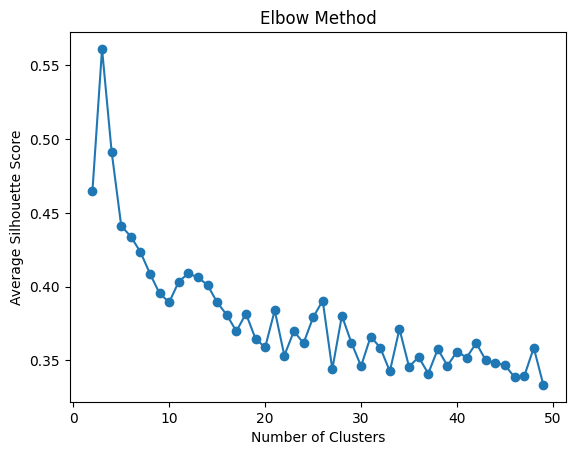

In [364]:
plt.plot(clusters, ss_list, marker='o')
plt.xlabel('Number of Clusters');
plt.ylabel('Average Silhouette Score');
plt.title('Elbow Method')
plt.show()

In [367]:
#agrupamentos
c_kmeans = ss_list.index(max(ss_list)) + 2
print('Best K: {}'.format(c_kmeans))

Best K: 3


In [368]:
#definição do modelo
kmeans = ct.KMeans(n_clusters=c_kmeans, init='random', n_init=10, random_state=0)
#fitting the model
labels = kmeans.fit_predict(X_pca)

In [369]:
#performance
ss_avg = mt.silhouette_score(X_pca, labels)
print('Silhouette Score: {}'.format(ss_avg))

Silhouette Score: 0.5601697480957203


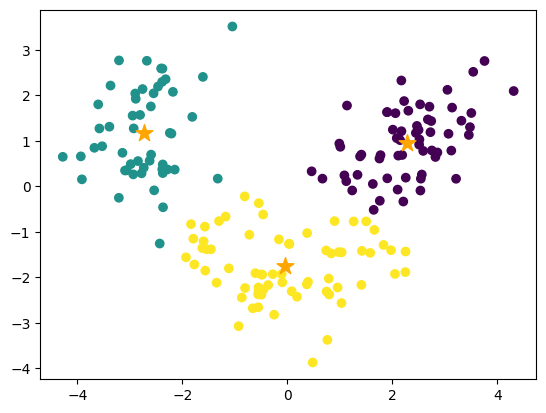

In [ ]:
#draw figure
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)

for i in range(len(kmeans.cluster_centers_)):
    plt.scatter(kmeans.cluster_centers_[i,0], kmeans.cluster_centers_[i,1], c='orange', marker='*', s=160)

# Affinity Propagation

Nesta seção são realizados os seguintes passos para o algoritmo Affinity Propagation:

- Normalização dos dados com `StandardScaler`.
- Redução dimensional para 2 componentes com `PCA`.
- Teste de diferentes valores de `preference` para encontrar o melhor ajuste do modelo.
- Cálculo do `silhouette_score` para cada configuração, acompanhando a convergência.
- Seleção do melhor `preference` com base na maior pontuação de silhueta.
- Treinamento final do modelo e visualização dos clusters em 2D.
- Exibição do número de clusters formados e da qualidade do agrupamento.

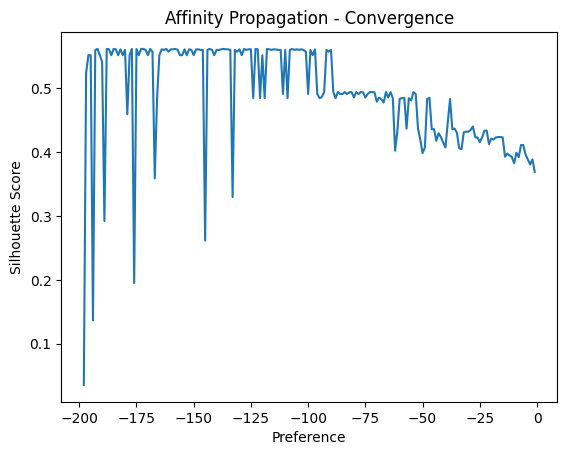

<Figure size 640x480 with 0 Axes>

In [358]:
#scaling the data
scaler_af = ss()
X_scaled_af = scaler_af.fit_transform(X_train)

#reduzindo colunas ruidozas
pca_af = PCA(n_components=2)
X_pca_af = pca_af.fit_transform(X_scaled_af)

#Convergency testing
p_af = np.arange(-1,-200,-1)
ss_list_af = []

for i in range(len(p_af)):
    model_af = ct.AffinityPropagation(preference= p_af[i])
    model_af.fit(X_pca_af)

    labels_af = model_af.predict(X_pca_af)

    #metric
    ss_avg_af = mt.silhouette_score(X_pca_af, labels_af)
    ss_list_af.append(ss_avg_af)
    
    #plot
    plt.plot(p_af[:i], ss_list_af[:i])

    #plot
    plt.title( 'Affinity Propagation - Convergence' );
    plt.xlabel( 'Preference' );
    plt.ylabel( 'Silhouette Score' )
    clear_output(wait=True)
    plt.show()
    plt.gcf()
    time.sleep(0.001)

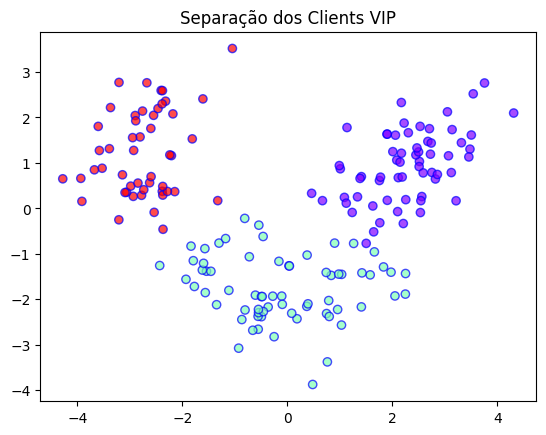

In [359]:
# Showing final Clustering
max_index = ss_list_af.index( max( ss_list_af ) )
af = ct.AffinityPropagation( preference=p_af[max_index] )
clustering = af.fit(X_pca_af)
fig = plt.figure()
plt.title( "Separação dos Clients VIP")
plt.scatter(X_pca_af[:,0], X_pca_af[:,1], c=clustering.labels_, cmap='rainbow', alpha=0.7, edgecolors='b');

In [360]:
n_clusters = len(af.cluster_centers_indices_)
print("Number of clusters:", n_clusters)
print("Best Preference: {}".format(p_af[max_index]))
print("Silhouette Score:", ss_list_af[max_index])


Number of clusters: 3
Best Preference: -128
Silhouette Score: 0.5615381093536467


In [361]:
unique, counts = np.unique(labels_af, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(57), np.int64(1): np.int64(72), np.int64(2): np.int64(49)}


# Resultados

In [371]:
# criar tabela com os resultados da performace dos algorítimos de classificação com dados de validação
resultados = pd.DataFrame(columns=['Nome_do_algoritmo', 'Número de clusters', 'Average Silhouette Score'])

# adicionar os resultados à tabela
resultados.loc[0] = ['K-Means', c_kmeans, ss_avg]
resultados.loc[1] = ['Affinity Propagation', n_clusters, ss_avg_af]

# Transforma o MAPE em porcentagem com 3 casas
#resultados['k-Means'] = resultados['k-Means'].apply(lambda x: f"{x:.3f}")
#resultados['Affinity Propagation'] = resultados['Affinity Propagation'].apply(lambda x: f"{x:.3f}")

resultados = resultados.reset_index(drop=True)
resultados

,Nome_do_algoritmo,Número de clusters,Average Silhouette Score
0,K-Means,3,0.560170
1,Affinity Propagation,3,0.551746
